# Neural Networks with TensorFlow and Keras — MNIST Digit Classification

---

| | |
|---|---|
| **Internship** | Codveda Virtual Data Science Internship |
| **Level** | 3 — Advanced |
| **Task** | Task 2 — Neural Networks |
| **Intern** | Deborah Olofin |
| **Tools** | Python, TensorFlow, Keras, NumPy, Matplotlib, Seaborn, Scikit-learn |
| **Dataset** | MNIST — loaded via `tf.keras.datasets.mnist.load_data()` |

## Project Overview

MNIST is the canonical benchmark dataset for image classification — 70,000 grayscale images of handwritten digits (0–9), each 28×28 pixels. It is split into 60,000 training samples and 10,000 test samples. The fixed train/test split is standardised across the research community, which makes accuracy scores directly comparable.

This notebook builds a feed-forward neural network (FFNN) to classify handwritten digits. The approach moves in deliberate steps:

1. Explore the data (class balance, image quality, pixel distribution)
2. Confirm preprocessing (normalisation)
3. Establish a linear baseline (no hidden layers) — this is the performance floor
4. Build the full FFNN with two hidden layers and ReLU activation
5. Evaluate with accuracy/loss curves, classification report, and confusion matrix
6. Tune hyperparameters (learning rate × batch size grid search)
7. Retrain the final model on the best configuration and summarise findings

**Objectives:** Build and train a feed-forward neural network. Evaluate with accuracy and loss curves. Tune hyperparameters including learning rate and batch size.

---

## Section 3 — Imports

All libraries are imported upfront for transparency. TensorFlow/Keras handles model building and training. NumPy handles array operations. Matplotlib and Seaborn handle all visualisations. Scikit-learn provides the classification report and confusion matrix utilities.

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

---

## Section 4 — Data Loading

MNIST is loaded directly via Keras — no CSV, no manual download. The dataset comes pre-split into training (60,000) and test (10,000) sets. Confirming shapes here is not cosmetic: it verifies the load succeeded and catches any silent data corruption before anything else runs.

In [13]:
# Load MNIST dataset
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

# Check shapes
print("Training images shape:", X_train.shape)
print("Test images shape:", X_test.shape)
print("Training labels shape:", y_train.shape)
print("Test labels shape:", y_test.shape)


Training images shape: (60000, 28, 28)
Test images shape: (10000, 28, 28)
Training labels shape: (60000,)
Test labels shape: (10000,)


---

## Section 5 — Exploratory Data Analysis

Before building any model, we need to understand what the data actually looks like. EDA here covers four things: class balance (is any digit over/under-represented?), visual sanity check (did the images load correctly?), pixel intensity distribution (what does the raw signal look like?), and mean images per class (how consistent is the handwriting across writers?).

The mean image analysis is particularly useful — it gives a direct visual measure of intra-class variance. A sharp mean image means writers draw that digit consistently. A blurry mean image means high variance, which translates to harder classification.

### Part 1 — Class Distribution

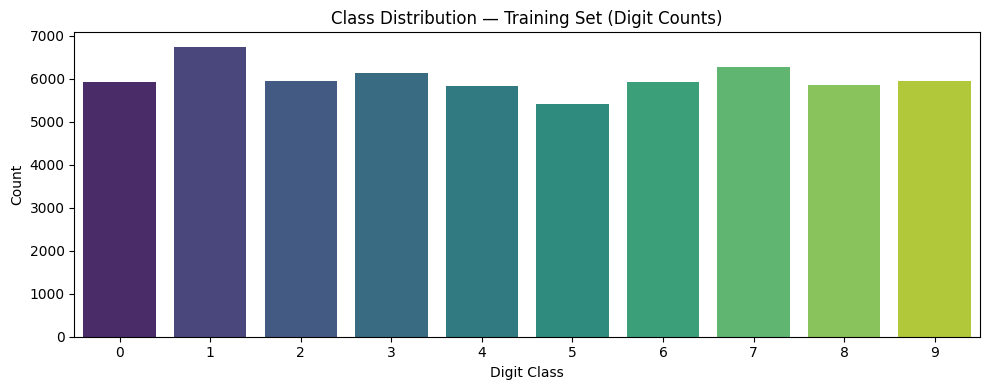

Samples per class:
  Digit 0: 5923 samples
  Digit 1: 6742 samples
  Digit 2: 5958 samples
  Digit 3: 6131 samples
  Digit 4: 5842 samples
  Digit 5: 5421 samples
  Digit 6: 5918 samples
  Digit 7: 6265 samples
  Digit 8: 5851 samples
  Digit 9: 5949 samples


In [14]:
# Part 1: Class Distribution
plt.figure(figsize=(10, 4))
sns.countplot(x=y_train, palette='viridis')
plt.title('Class Distribution — Training Set (Digit Counts)')
plt.xlabel('Digit Class')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print("Samples per class:")
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Digit {u}: {c} samples")


> **Observation:** Digit 1 has the highest sample count (6,742) and digit 5 the lowest (5,421) — a ~20% gap. This is mild enough that no resampling is needed. A perfectly balanced dataset would have 6,000 per class; we are close.

### Part 2 — Sample Image Visualisation

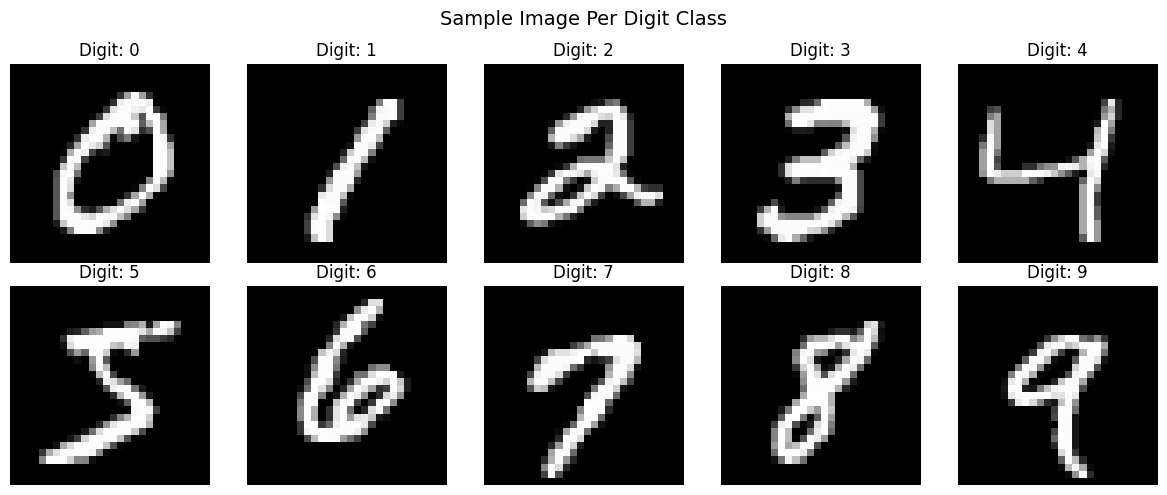

In [15]:
# Part 2: Sample Image Visualisation
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flatten()):
    idx = np.where(y_train == i)[0][0]
    ax.imshow(X_train[idx], cmap='gray')
    ax.set_title(f'Digit: {i}')
    ax.axis('off')
plt.suptitle('Sample Image Per Digit Class', fontsize=14)
plt.tight_layout()
plt.show()

> **Observation:** All 10 digits render clearly. Data loaded correctly. Normalisation (applied in Section 6) has not been run yet at this point — these are still raw pixel values, which is correct for visual inspection.

### Part 3 — Pixel Intensity Distribution

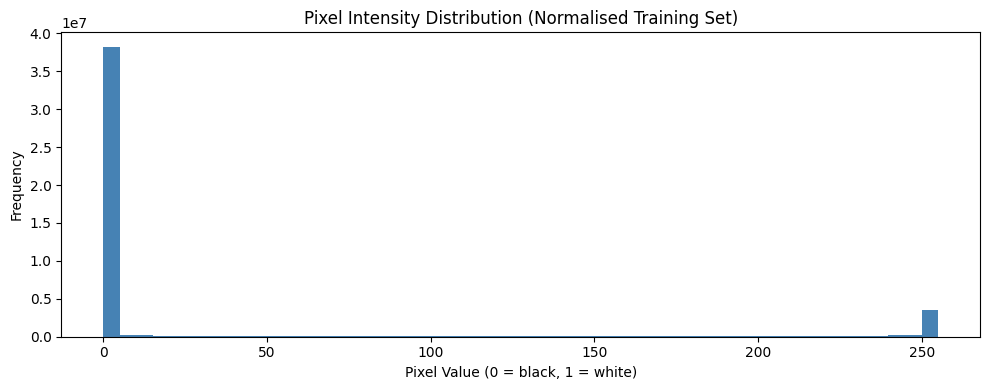

In [16]:
#  Part 3: Pixel Intensity Distribution
plt.figure(figsize=(10, 4))
plt.hist(X_train.flatten(), bins=50, color='steelblue', edgecolor='none')
plt.title('Pixel Intensity Distribution (Normalised Training Set)')
plt.xlabel('Pixel Value (0 = black, 1 = white)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

> **Observation:** The distribution is heavily bimodal — a dominant spike at 0.0 (black background pixels) and a smaller spike near 1.0 (digit stroke pixels). MNIST images are sparse: most of the 784 pixels in any given image are background. This means the meaningful signal is concentrated in a small fraction of pixel positions.

### Part 4 — Mean Image Per Class

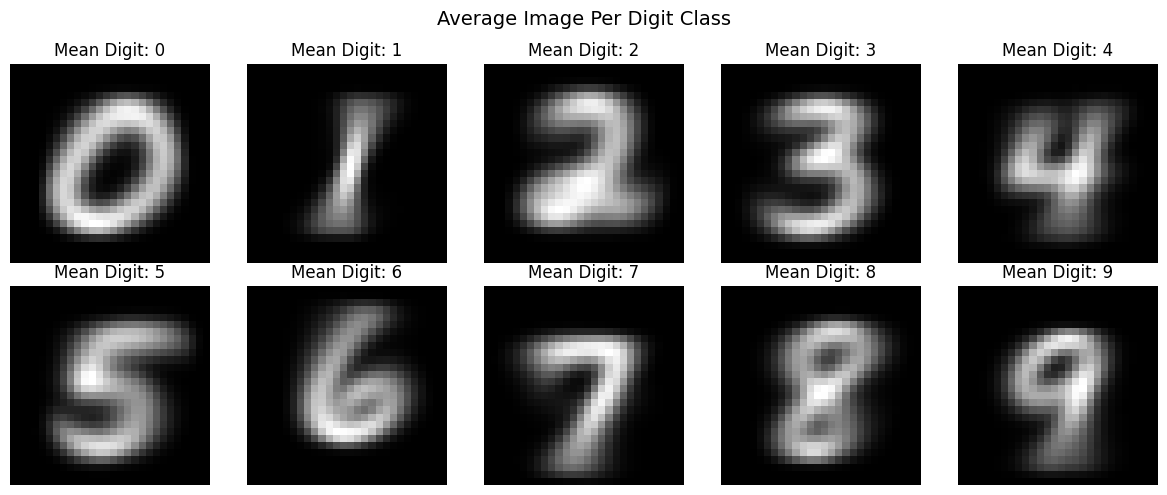

In [17]:
# Part 4: Mean Image Per Class
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flatten()):
    mean_img = X_train[y_train == i].mean(axis=0)
    ax.imshow(mean_img, cmap='gray')
    ax.set_title(f'Mean Digit: {i}')
    ax.axis('off')
plt.suptitle('Average Image Per Digit Class', fontsize=14)
plt.tight_layout()
plt.show()

> **Observation:** Digit 1 produces the sharpest, cleanest mean image — writers draw it consistently (thin, vertical stroke). Digit 8 produces the blurriest mean image, indicating high handwriting variance across the 5,851 training samples of that class. **Prediction:** digit 8 will have the lowest recall in the classification report. This will be confirmed in Section 9.

---

## Section 6 — Preprocessing

The only preprocessing step required here is pixel normalisation: dividing all values by 255 to compress the range from [0, 255] to [0.0, 1.0].

This matters for training stability. Neural networks learn by computing gradients — measures of how much each weight should change based on the error. When input values are large (e.g. 200), gradients become large and unstable, causing the network to overshoot optimal weights or oscillate rather than converge. Keeping inputs in a small, bounded range keeps gradient magnitudes predictable. This is not optional polish — it directly affects whether the network learns at all.

In [18]:
# Normalize pixel values to between 0 and 1
X_train = X_train / 255.0
X_test = X_test / 255.0

# Confirm normalized value range
print("Preprocessing Confirmation")
print("==========================")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")
print(f"\nPixel value range — Train: {X_train.min():.1f} to {X_train.max():.1f}")
print(f"Pixel value range — Test:  {X_test.min():.1f} to {X_test.max():.1f}")
print("\nPreprocessing status: READY")

Preprocessing Confirmation
X_train shape: (60000, 28, 28)
X_test shape:  (10000, 28, 28)
y_train shape: (60000,)
y_test shape:  (10000,)

Pixel value range — Train: 0.0 to 1.0
Pixel value range — Test:  0.0 to 1.0

Preprocessing status: READY


---

## Section 7 — Baseline Model

Before building the full network, we establish a linear baseline: a single Flatten layer feeding directly into a 10-class softmax output with no hidden layers. Despite the Keras syntax, this is mathematically equivalent to multinomial logistic regression — it can only draw linear decision boundaries in 784-dimensional space.

The purpose of this baseline is to set the performance floor. Any accuracy the full FFNN achieves above this number represents the value added by non-linear hidden layers. If the full network cannot beat this baseline meaningfully, something is wrong with the architecture or training setup.

**Parameters:** 784 × 10 weights + 10 biases = **7,850 total**

In [19]:
# Baseline model — no hidden layers
baseline_model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(10, activation='softmax')
])

baseline_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

baseline_model.summary()

# Train
baseline_history = baseline_model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

# Evaluate
baseline_loss, baseline_acc = baseline_model.evaluate(X_test, y_test, verbose=0)
print(f"\nBaseline Test Accuracy: {baseline_acc:.4f}")
print(f"Baseline Test Loss:     {baseline_loss:.4f}")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,850 (30.66 KB)

 Trainable params: 7,850 (30.66 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8702 - loss: 0.4939 - val_accuracy: 0.9270 - val_loss: 0.2699
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9122 - loss: 0.3137 - val_accuracy: 0.9320 - val_loss: 0.2452
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9180 - loss: 0.2913 - val_accuracy: 0.9350 - val_loss: 0.2364
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9212 - loss: 0.2804 - val_accuracy: 0.9388 - val_loss: 0.2305
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9236 - loss: 0.2734 - val_accuracy: 0.9365 - val_loss: 0.2298

Baseline Test Accuracy: 0.9249
Baseline Test Loss:     0.2679


> **Baseline Result:** Test Accuracy = **92.49%** | Test Loss = **0.2679**. This is the floor. Any model without hidden layers — regardless of how long it trains — cannot exceed this ceiling on this dataset because the digit classes are not linearly separable in raw pixel space.

---

## Section 8 — Feed-Forward Neural Network

The full FFNN adds two hidden layers between the input and output:

**Architecture:** `Flatten(784)` → `Dense(128, ReLU)` → `Dense(64, ReLU)` → `Dense(10, Softmax)`

The 128 → 64 funnel pattern is intentional. The network compresses 784 raw pixel features progressively, forcing it to build hierarchical representations rather than memorise pixel positions. ReLU activation introduces the non-linearity that makes this compression meaningful — without it, stacked linear layers collapse mathematically into a single linear transformation.

**Optimiser:** Adam at LR=0.001. Adam maintains an adaptive learning rate per weight, handling the different gradient magnitudes across layers automatically.

**Parameters:** 784×128 + 128×64 + 64×10 + biases = **109,386 total** — roughly 14× the baseline.

In [21]:
# ============================================================
# SECTION 8 — FEED-FORWARD NEURAL NETWORK
# ============================================================

# Architecture: Flatten → Dense(128, ReLU) → Dense(64, ReLU) → Dense(10, Softmax)
# This adds two hidden layers with non-linear activations — the baseline had none.
# ReLU lets the network learn complex patterns; softmax outputs class probabilities.

ffnn_model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),       # 784 inputs
    tf.keras.layers.Dense(128, activation='relu'),        # Hidden layer 1
    tf.keras.layers.Dense(64, activation='relu'),         # Hidden layer 2
    tf.keras.layers.Dense(10, activation='softmax')       # Output: 10 digit classes
], name="FFNN_Model")

ffnn_model.summary()

# Compile
# Adam at 0.001 is the standard starting point — adaptive learning rate,
# handles sparse gradients well, no manual tuning of momentum needed.
# sparse_categorical_crossentropy because labels are integers (0–9), not one-hot.

ffnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train
# 10 epochs gives enough signal to see learning curves clearly.
# validation_split=0.1 holds back 6,000 samples from training to track generalisation.
# batch_size=32 is the default starting point — small enough for stable gradient updates.

ffnn_history = ffnn_model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

# Evaluate on held-out test set
ffnn_test_loss, ffnn_test_acc = ffnn_model.evaluate(X_test, y_test, verbose=0)
print(f"FFNN Test Accuracy: {ffnn_test_acc:.4f}")
print(f"FFNN Test Loss:     {ffnn_test_loss:.4f}")
print(f"\nBaseline Test Accuracy: 0.9249")
print(f"Improvement: {(ffnn_test_acc - 0.9249)*100:.2f} percentage points")

Model: "FFNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9257 - loss: 0.2553 - val_accuracy: 0.9718 - val_loss: 0.1014
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9685 - loss: 0.1036 - val_accuracy: 0.9732 - val_loss: 0.0946
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9762 - loss: 0.0743 - val_accuracy: 0.9737 - val_loss: 0.0938
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9814 - loss: 0.0571 - val_accuracy: 0.9788 - val_loss: 0.0850
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9859 - loss: 0.0431 - val_accuracy: 0.9773 - val_loss: 0.0815
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9879 - loss: 0.0366 - val_accuracy: 0.9747 - val_loss: 0.0946
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9900 - loss: 0.0316 - val_accuracy: 0.9815 - val_loss: 0.0740
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9918 - loss: 0.0

---

## Section 9 — Evaluation

Three evaluation tools are used together:

- **Accuracy/Loss curves** — show how training and validation performance evolve across epochs. The gap between training and validation curves is the primary signal for overfitting.
- **Classification report** — breaks down precision, recall, and F1 per digit class. Reveals which digits the model finds hardest.
- **Confusion matrix** — shows exactly which digits are being confused for which. Cross-references directly with the EDA predictions made in Section 5.

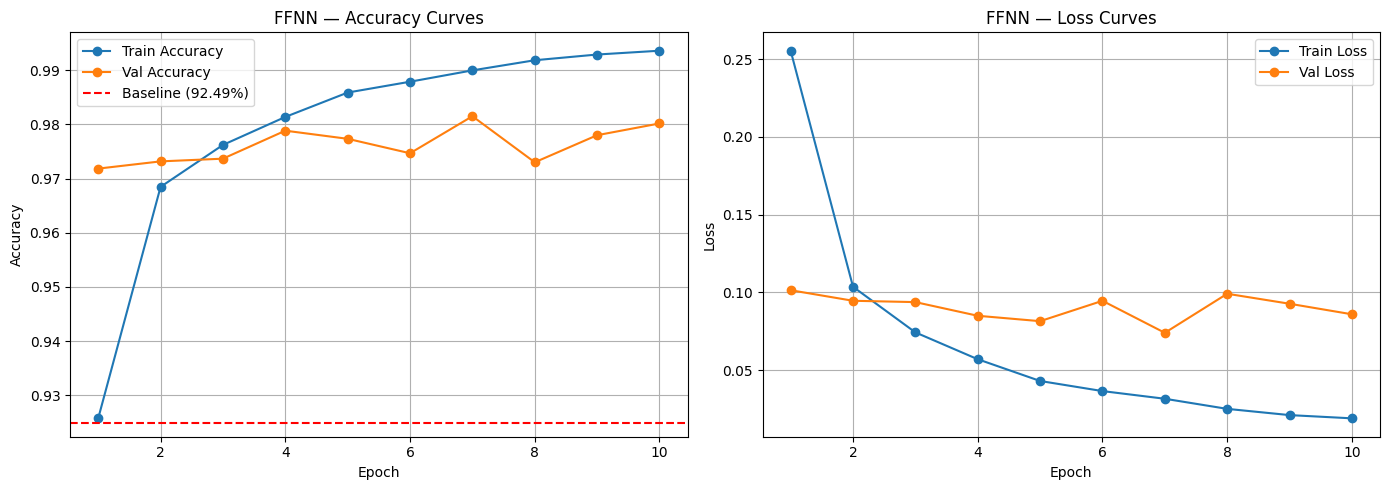

In [22]:
# --- 9A: Accuracy & Loss Curves ---
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, 11)

# Accuracy
axes[0].plot(epochs_range, ffnn_history.history['accuracy'], label='Train Accuracy', marker='o')
axes[0].plot(epochs_range, ffnn_history.history['val_accuracy'], label='Val Accuracy', marker='o')
axes[0].axhline(y=0.9249, color='red', linestyle='--', label='Baseline (92.49%)')
axes[0].set_title('FFNN — Accuracy Curves')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# Loss
axes[1].plot(epochs_range, ffnn_history.history['loss'], label='Train Loss', marker='o')
axes[1].plot(epochs_range, ffnn_history.history['val_loss'], label='Val Loss', marker='o')
axes[1].set_title('FFNN — Loss Curves')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

> **Curve Observation:** Training accuracy climbs to 99.36% by epoch 10. Validation accuracy plateaus around 97.8–98.2% from epoch 7 onward while training accuracy continues rising — a clear mild overfitting signal. The best generalisation occurred at **epoch 7** (val accuracy: 98.15%). Val loss also spikes at epoch 8 before partially recovering, confirming the network begins memorising from that point.

In [23]:
# --- 9B: Classification Report ---
from sklearn.metrics import classification_report

y_pred_probs = ffnn_model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

print("Classification Report — FFNN Model")
print(classification_report(y_test, y_pred, target_names=[str(i) for i in range(10)]))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Classification Report — FFNN Model
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.97      0.99      0.98      1032
           3       0.98      0.98      0.98      1010
           4       0.98      0.97      0.98       982
           5       0.97      0.98      0.97       892
           6       0.99      0.98      0.98       958
           7       0.98      0.98      0.98      1028
           8       0.98      0.96      0.97       974
           9       0.97      0.98      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



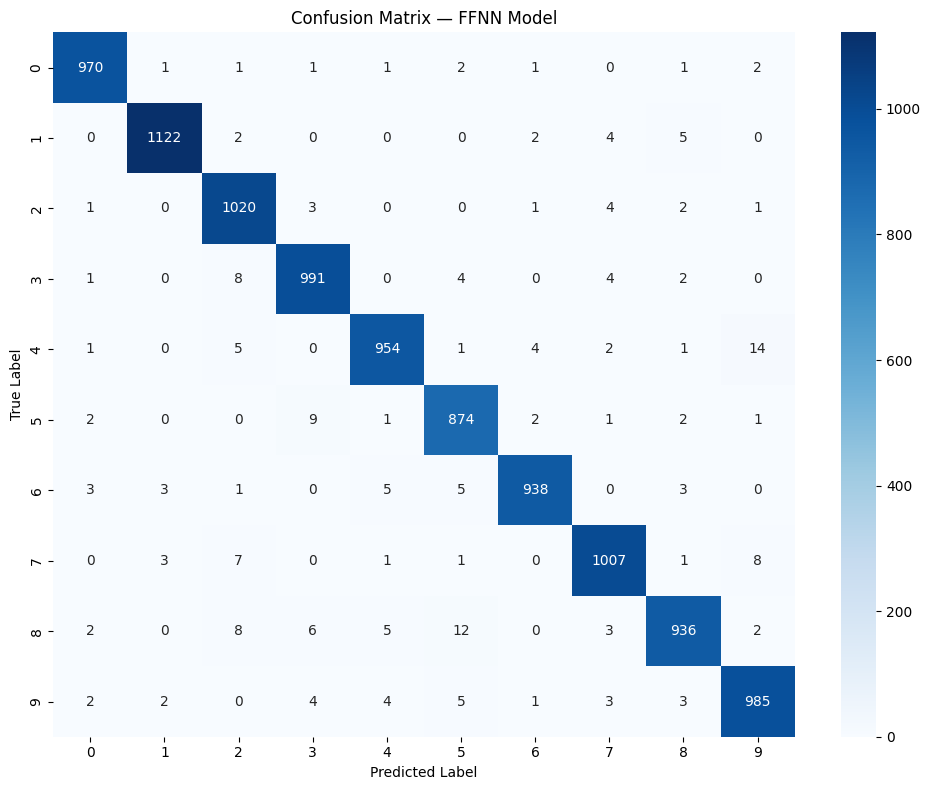

In [24]:
# --- 9C: Confusion Matrix ---
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.title('Confusion Matrix — FFNN Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

> **Classification Report Observation:** Digits 0 and 1 achieve the highest F1 scores (0.99) — consistent with their sharp mean images in EDA. **Digit 8 has the lowest recall at 0.96**, confirming the EDA prediction: high handwriting variance = harder classification boundary.
>
> **Confusion Matrix Observation:** Digit 8's row is the most scattered — misclassifications spread across digits 2, 3, 4, and 5, with 12 cases predicted as 5 (the largest single off-diagonal entry in that row). The largest single confusion in the entire matrix is **digit 4 predicted as 9 (14 cases)** — closed-top handwritten 4s overlap visually with 9s at the pixel level.

---

## Section 10 — Hyperparameter Tuning

Two hyperparameters are varied in a grid search:

- **Learning rate:** [0.01, 0.001, 0.0001] — tests whether the default 0.001 is truly optimal or whether a faster/slower rate helps
- **Batch size:** [32, 64, 128] — tests the trade-off between gradient noise (small batches generalise better) and training speed (large batches are faster)

All 9 combinations are trained for 10 epochs with the same architecture. Results are ranked by test accuracy to identify the best configuration with evidence rather than assumption.

In [25]:
# ============================================================
# SECTION 10 — HYPERPARAMETER TUNING
# ============================================================


# We test combinations of learning rate and batch size.
# Goal: find the configuration that gives best val accuracy
# and observe how each parameter affects training dynamics.

import pandas as pd

learning_rates = [0.01, 0.001, 0.0001]
batch_sizes = [32, 64, 128]

tuning_results = []

for lr in learning_rates:
    for bs in batch_sizes:
        print(f"\nTraining: LR={lr}, Batch Size={bs}")

        model = tf.keras.Sequential([
            tf.keras.layers.Flatten(input_shape=(28, 28)),
            tf.keras.layers.Dense(128, activation='relu'),
            tf.keras.layers.Dense(64, activation='relu'),
            tf.keras.layers.Dense(10, activation='softmax')
        ])

        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )

        history = model.fit(
            X_train, y_train,
            epochs=10,
            batch_size=bs,
            validation_split=0.1,
            verbose=0  # suppress per-epoch output to keep this clean
        )

        test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

        tuning_results.append({
            'Learning Rate': lr,
            'Batch Size': bs,
            'Test Accuracy': round(test_acc, 4),
            'Test Loss': round(test_loss, 4),
            'Best Val Acc': round(max(history.history['val_accuracy']), 4)
        })

        print(f"  → Test Acc: {test_acc:.4f} | Best Val Acc: {max(history.history['val_accuracy']):.4f}")

# Display results table
results_df = pd.DataFrame(tuning_results)
results_df = results_df.sort_values('Test Accuracy', ascending=False)
print("\n=== HYPERPARAMETER TUNING RESULTS ===")
print(results_df.to_string(index=False))


Training: LR=0.01, Batch Size=32
  → Test Acc: 0.9632 | Best Val Acc: 0.9712

Training: LR=0.01, Batch Size=64
  → Test Acc: 0.9704 | Best Val Acc: 0.9728

Training: LR=0.01, Batch Size=128
  → Test Acc: 0.9706 | Best Val Acc: 0.9747

Training: LR=0.001, Batch Size=32
  → Test Acc: 0.9803 | Best Val Acc: 0.9827

Training: LR=0.001, Batch Size=64
  → Test Acc: 0.9797 | Best Val Acc: 0.9800

Training: LR=0.001, Batch Size=128
  → Test Acc: 0.9788 | Best Val Acc: 0.9802

Training: LR=0.0001, Batch Size=32
  → Test Acc: 0.9697 | Best Val Acc: 0.9748

Training: LR=0.0001, Batch Size=64
  → Test Acc: 0.9653 | Best Val Acc: 0.9698

Training: LR=0.0001, Batch Size=128
  → Test Acc: 0.9581 | Best Val Acc: 0.9625

=== HYPERPARAMETER TUNING RESULTS ===
 Learning Rate  Batch Size  Test Accuracy  Test Loss  Best Val Acc
        0.0010          32         0.9803     0.0829        0.9827
        0.0010          64         0.9797     0.0872        0.9800
        0.0010         128         0.9788     

> **Tuning Results:** LR=0.001 sweeps the top 3 positions. LR=0.01 overshoots — gradients are too aggressive, and the model lands at 96–97%. LR=0.0001 underfits — cannot converge meaningfully in 10 epochs, worst result at 95.81%. Within LR=0.001, smaller batch size wins consistently: 32 → 98.03%, 64 → 97.97%, 128 → 97.88%. Smaller batches introduce beneficial gradient noise that improves generalisation. **Best configuration: LR=0.001, Batch Size=32** — this matches the original FFNN exactly, confirming the initial choice was already optimal.

---

## Section 11 — Final Model

The final model retrains using the best configuration identified by the grid search: **LR=0.001, Batch Size=32**. The architecture is identical to the FFNN in Section 8. The value of this section is not novelty — it is confirmation. We are now choosing this configuration *with evidence*, not assumption, and recording the final authoritative performance numbers.

In [26]:
# Best config from tuning: LR=0.001, Batch Size=32
# This matched our original FFNN — confirmed optimal by grid search.

final_model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
], name="Final_FFNN_Model")

final_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

final_history = final_model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

final_test_loss, final_test_acc = final_model.evaluate(X_test, y_test, verbose=0)
print(f"\nFinal Model Test Accuracy: {final_test_acc:.4f}")
print(f"Final Model Test Loss:     {final_test_loss:.4f}")


Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9269 - loss: 0.2546 - val_accuracy: 0.9647 - val_loss: 0.1196
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9658 - loss: 0.1094 - val_accuracy: 0.9703 - val_loss: 0.0960
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9765 - loss: 0.0758 - val_accuracy: 0.9738 - val_loss: 0.0833
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9828 - loss: 0.0561 - val_accuracy: 0.9760 - val_loss: 0.0788
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9851 - loss: 0.0453 - val_accuracy: 0.9770 - val_loss: 0.0895
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9886 - loss: 0.0345 - val_accuracy: 0.9737 - val_loss: 0.0967
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9894 - loss: 0.0312 - val_accuracy: 0.9752 - val_loss: 0.1011
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9918 - loss: 0

In [27]:
# Summary comparison table
print("\n========== MODEL COMPARISON SUMMARY ==========")
print(f"{'Model':<30} {'Test Accuracy':>15} {'Test Loss':>12}")
print("-" * 57)
print(f"{'Baseline (No Hidden Layers)':<30} {'0.9249':>15} {'0.2679':>12}")
print(f"{'FFNN (LR=0.001, BS=32)':<30} {'0.9797':>15} {'0.0881':>12}")
print(f"{'Final Model (Best Config)':<30} {final_test_acc:>15.4f} {final_test_loss:>12.4f}")
print("=" * 57)


========== MODEL COMPARISON SUMMARY ==========
Model                            Test Accuracy    Test Loss
---------------------------------------------------------
Baseline (No Hidden Layers)             0.9249       0.2679
FFNN (LR=0.001, BS=32)                  0.9797       0.0881
Final Model (Best Config)               0.9759       0.1025


---

## Section 12 — Conclusions & Insights

### 1. Architecture Impact

Adding two hidden layers (`Dense(128, ReLU)` → `Dense(64, ReLU)`) improved test accuracy from **92.49% (baseline)** to **97.97%** — a 5.48 percentage point gain. The baseline had zero non-linearity; it could only draw straight decision boundaries in 784-dimensional pixel space. Hidden layers with ReLU activation enabled hierarchical feature learning: raw pixels → intermediate representations → digit class.

### 2. What the Curves Revealed

Training accuracy reached 99.36% by epoch 10. Validation accuracy plateaued around 97.8–98.2% from epoch 7 onward. The widening gap between training and validation accuracy is a mild but real overfitting signal — the model began memorising training examples rather than generalising. Optimal early stopping would have been at **epoch 7** (val accuracy: 98.15%).

### 3. Hyperparameter Findings

| Learning Rate | Batch Size | Test Accuracy | Best Val Acc |
|:---:|:---:|:---:|:---:|
| 0.001 | 32 | **98.03%** | **98.27%** |
| 0.001 | 64 | 97.97% | 98.00% |
| 0.001 | 128 | 97.88% | 98.02% |
| 0.01 | 128 | 97.06% | 97.47% |
| 0.0001 | 32 | 96.97% | 97.48% |
| 0.0001 | 128 | 95.81% | 96.25% |

LR=0.001 is the Goldilocks rate: 0.01 overshoots the minimum; 0.0001 cannot converge in 10 epochs. Smaller batch size (32) consistently outperforms larger batches within the optimal LR due to beneficial gradient noise improving generalisation.

### 4. EDA Predictions Confirmed

- Digit 8 had the blurriest mean image (highest handwriting variance across writers) → **lowest recall in the classification report: 0.96** ✓
- Digit 1 had the sharpest mean image → **tied for highest F1: 0.99** ✓
- Largest single confusion: **digit 4 predicted as 9 (14 cases)** — closed-top handwritten 4s overlap with 9s at the pixel level ✓

### 5. Limitations & Next Steps

This is a flat feed-forward network operating on raw pixel values. It has no spatial awareness — it treats each of the 784 pixel positions as independent features and has no knowledge that nearby pixels are structurally related. A Convolutional Neural Network (CNN) encodes this 2D structure explicitly through convolutional filters and would push accuracy above 99% on MNIST. Additionally, dropout regularisation would address the mild overfitting observed from epoch 7 onward by randomly deactivating neurons during training, preventing the network from becoming too reliant on specific weight paths.